# RNA-seq Quality Control and Alignment Summary
### *Anopheles coluzzii* — Ngousso colony vs field-collected mosquitoes (Akoda, Osun State, Nigeria)

**Imports and plotting configuration**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
from pathlib import Path

plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelweight"] = "bold"
plt.rcParams["axes.titlesize"] = 17
plt.rcParams["axes.labelsize"] = 13
plt.rcParams["xtick.labelsize"] = 11.5
plt.rcParams["ytick.labelsize"] = 11.5
plt.rcParams["legend.fontsize"] = 11.5
plt.rcParams["figure.dpi"] = 150
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.linewidth"] = 1.4
plt.rcParams["xtick.major.width"] = 1.4
plt.rcParams["ytick.major.width"] = 1.4

OUTDIR = Path("/mnt/hpc_acegid/home/khadmig/work/data/For_Lynda/260718_VH00635_9_AAJ2KFGM5/output_analysis")
MQC = OUTDIR / "multiqc" / "multiqc_data"
SALMON_DIR = OUTDIR / "salmon"
FIGDIR = Path("figures")
FIGDIR.mkdir(exist_ok=True)

SAMPLES = ["Ng1", "Ng2", "Ng3", "NE1", "NE2", "NE3"]
GROUP = {
    "Ng1": "Ngousso colony",
    "Ng2": "Ngousso colony",
    "Ng3": "Ngousso colony",
    "NE1": "Field (Akoda)",
    "NE2": "Field (Akoda)",
    "NE3": "Field (Akoda)",
}
GROUP_COLOR = {"Ngousso colony": "#1B4F72", "Field (Akoda)": "#B03A2E"}
SAMPLE_COLOR = {s: GROUP_COLOR[GROUP[s]] for s in SAMPLES}


def bold_ticks(ax):
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight("bold")


def legend_by_group(ax, loc="upper right"):
    handles = [plt.Rectangle((0, 0), 1, 1, color=GROUP_COLOR[g]) for g in GROUP_COLOR]
    ax.legend(handles, list(GROUP_COLOR.keys()), loc=loc, frameon=False)

**Pipeline workflow**

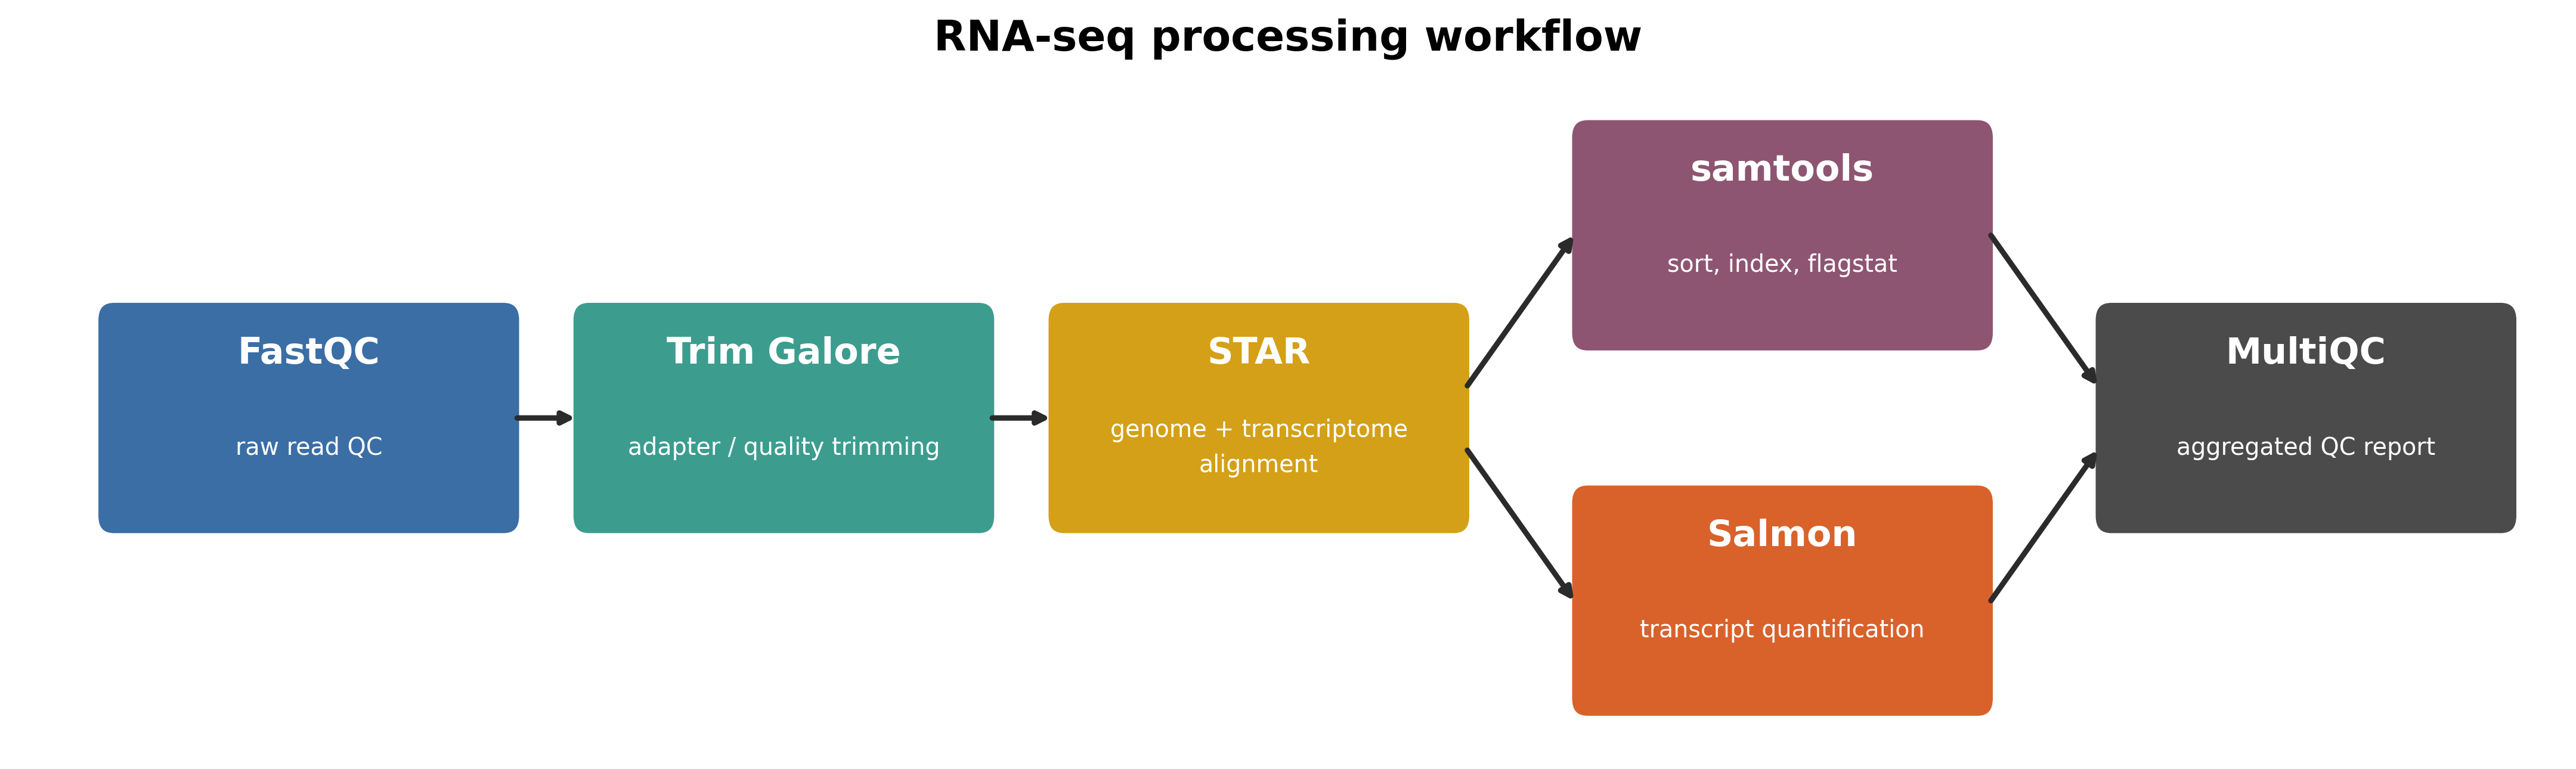

In [2]:
stages = [
    {"name": "FastQC", "sub": "raw read QC", "pos": (0.7, 1.0), "color": "#3B6EA5"},
    {"name": "Trim Galore", "sub": "adapter / quality trimming", "pos": (3.15, 1.0), "color": "#3C9D8F"},
    {"name": "STAR", "sub": "genome + transcriptome\nalignment", "pos": (5.6, 1.0), "color": "#D4A017"},
    {"name": "samtools", "sub": "sort, index, flagstat", "pos": (8.3, 1.85), "color": "#8E5572"},
    {"name": "Salmon", "sub": "transcript quantification", "pos": (8.3, 0.15), "color": "#D9622B"},
    {"name": "MultiQC", "sub": "aggregated QC report", "pos": (11.0, 1.0), "color": "#4B4B4B"},
]

box_w, box_h = 2.15, 1.05

fig, ax = plt.subplots(figsize=(14.5, 4.4))

for stage in stages:
    x, y = stage["pos"]
    box = FancyBboxPatch(
        (x - box_w / 2, y - box_h / 2),
        box_w,
        box_h,
        boxstyle="round,pad=0.02,rounding_size=0.09",
        linewidth=1.6,
        edgecolor="white",
        facecolor=stage["color"],
    )
    ax.add_patch(box)
    ax.text(x, y + 0.3, stage["name"], ha="center", va="center", fontsize=14.5, fontweight="bold", color="white")
    ax.text(x, y - 0.14, stage["sub"], ha="center", va="center", fontsize=9.5, color="white", linespacing=1.6)


def arrow(p_from, p_to):
    ax.annotate(
        "",
        xy=p_to,
        xytext=p_from,
        arrowprops=dict(arrowstyle="-|>", lw=2.2, color="#2B2B2B", shrinkA=0, shrinkB=0),
    )


fastqc, trim, star, samt, salmon, mqc = stages
arrow((fastqc["pos"][0] + box_w / 2, fastqc["pos"][1]), (trim["pos"][0] - box_w / 2, trim["pos"][1]))
arrow((trim["pos"][0] + box_w / 2, trim["pos"][1]), (star["pos"][0] - box_w / 2, star["pos"][1]))
arrow((star["pos"][0] + box_w / 2, star["pos"][1] + 0.15), (samt["pos"][0] - box_w / 2, samt["pos"][1]))
arrow((star["pos"][0] + box_w / 2, star["pos"][1] - 0.15), (salmon["pos"][0] - box_w / 2, salmon["pos"][1]))
arrow((samt["pos"][0] + box_w / 2, samt["pos"][1]), (mqc["pos"][0] - box_w / 2, mqc["pos"][1] + 0.15))
arrow((salmon["pos"][0] + box_w / 2, salmon["pos"][1]), (mqc["pos"][0] - box_w / 2, mqc["pos"][1] - 0.15))

ax.set_xlim(-0.8, 12.3)
ax.set_ylim(-0.55, 2.55)
ax.axis("off")
ax.set_title("RNA-seq processing workflow", pad=14)

plt.tight_layout()
plt.savefig(FIGDIR / "01_workflow.png", bbox_inches="tight")
plt.show()

**Load QC summary tables**

In [3]:
fastqc = pd.read_csv(MQC / "multiqc_fastqc.txt", sep="\t")
cutadapt = pd.read_csv(MQC / "multiqc_cutadapt.txt", sep="\t")
star = pd.read_csv(MQC / "multiqc_star.txt", sep="\t")
salmon = pd.read_csv(MQC / "multiqc_salmon.txt", sep="\t")

file_pattern = r"^(?P<sample>.+?)_S\d+_R(?P<mate>[12])_001$"

fastqc[["sample", "mate"]] = fastqc["Sample"].str.extract(file_pattern)
cutadapt[["sample", "mate"]] = cutadapt["Sample"].str.extract(file_pattern)
star = star[~star["Sample"].str.contains("STARpass1")].rename(columns={"Sample": "sample"}).set_index("sample").loc[SAMPLES]
salmon = salmon.rename(columns={"Sample": "sample"}).set_index("sample").loc[SAMPLES]

**Sequencing depth and read quality**

In [4]:
depth = fastqc.groupby("sample").agg(
    read_pairs=("Total Sequences", "first"),
    percent_gc=("%GC", "mean"),
    percent_duplication=("total_deduplicated_percentage", lambda x: 100 - x.mean()),
    mean_length=("avg_sequence_length", "mean"),
).loc[SAMPLES]

trimming = cutadapt.groupby("sample").agg(percent_trimmed=("percent_trimmed", "mean")).loc[SAMPLES]

summary_table = depth.join(trimming)
summary_table.insert(0, "group", [GROUP[s] for s in summary_table.index])
summary_table = summary_table.rename(columns={
    "group": "Group",
    "read_pairs": "Read pairs",
    "percent_gc": "GC content (%)",
    "percent_duplication": "Duplication (%)",
    "mean_length": "Mean read length (bp)",
    "percent_trimmed": "Bases trimmed (%)",
})

styled_summary = (
    summary_table.style
    .format({
        "Read pairs": "{:,.0f}",
        "GC content (%)": "{:.1f}",
        "Duplication (%)": "{:.1f}",
        "Mean read length (bp)": "{:.1f}",
        "Bases trimmed (%)": "{:.2f}",
    })
    .background_gradient(subset=["Duplication (%)"], cmap="Reds")
    .background_gradient(subset=["Read pairs"], cmap="Blues")
    .set_caption("Sequencing depth and read quality per sample")
    .set_table_styles([
        {"selector": "caption", "props": [("font-size", "15px"), ("font-weight", "bold"), ("text-align", "left"), ("padding-bottom", "8px")]},
        {"selector": "th", "props": [("font-weight", "bold"), ("background-color", "#F2F2F2")]},
    ])
)
styled_summary

,Group,Read pairs,GC content (%),Duplication (%),Mean read length (bp),Bases trimmed (%)
sample,,,,,,
Ng1,Ngousso colony,"91,669,812",55.5,91.7,138.4,0.61
Ng2,Ngousso colony,"69,085,711",55.0,90.1,138.7,0.57
Ng3,Ngousso colony,"82,571,903",54.0,89.7,135.3,0.72
NE1,Field (Akoda),"87,636,847",54.5,91.6,134.3,0.59
NE2,Field (Akoda),"81,923,162",55.0,90.8,131.8,0.71
NE3,Field (Akoda),"91,970,168",55.5,91.4,133.6,0.57


**Read pairs per sample**

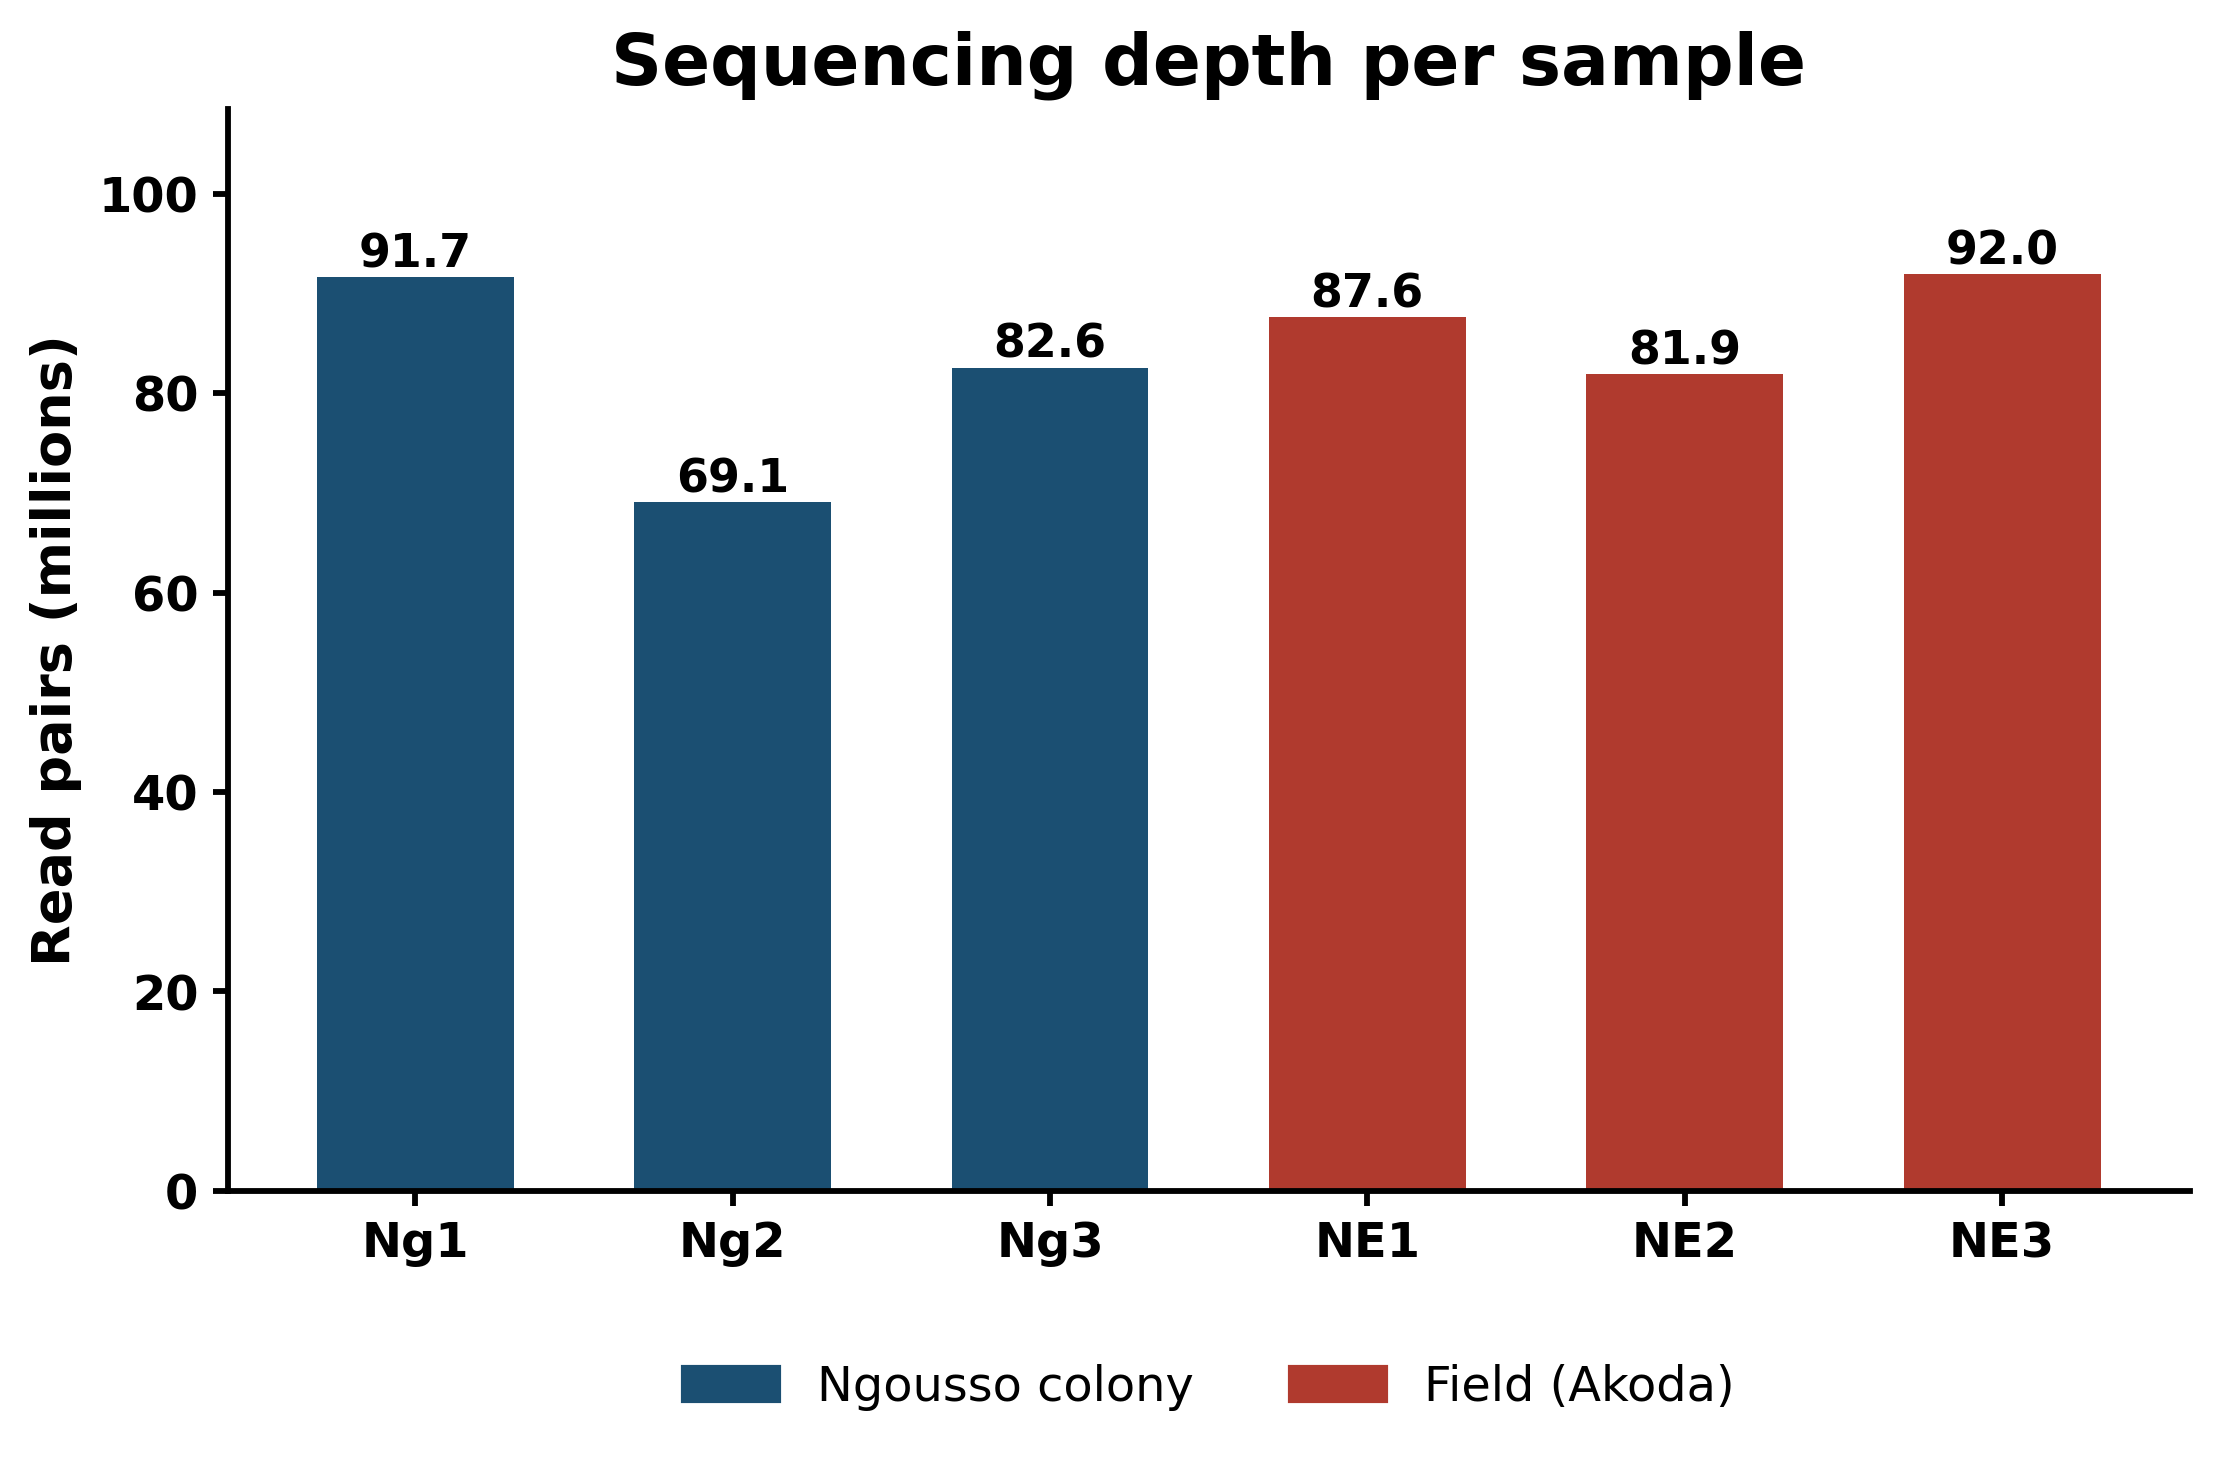

In [5]:
fig, ax = plt.subplots(figsize=(7.5, 5))
bars = ax.bar(SAMPLES, summary_table["Read pairs"] / 1e6, color=[SAMPLE_COLOR[s] for s in SAMPLES], width=0.62)

for bar, value in zip(bars, summary_table["Read pairs"] / 1e6):
    ax.text(bar.get_x() + bar.get_width() / 2, value + 1, f"{value:.1f}", ha="center", fontsize=11, fontweight="bold")

ax.set_ylabel("Read pairs (millions)")
ax.set_title("Sequencing depth per sample")
ax.set_ylim(0, summary_table["Read pairs"].max() / 1e6 * 1.18)
ax.legend(
    handles=[plt.Rectangle((0, 0), 1, 1, color=GROUP_COLOR[g]) for g in GROUP_COLOR],
    labels=list(GROUP_COLOR.keys()),
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=2,
    frameon=False,
)
bold_ticks(ax)

plt.tight_layout()
plt.savefig(FIGDIR / "02_read_depth.png", bbox_inches="tight")
plt.show()

**Alignment rate to the *Anopheles coluzzii* genome**

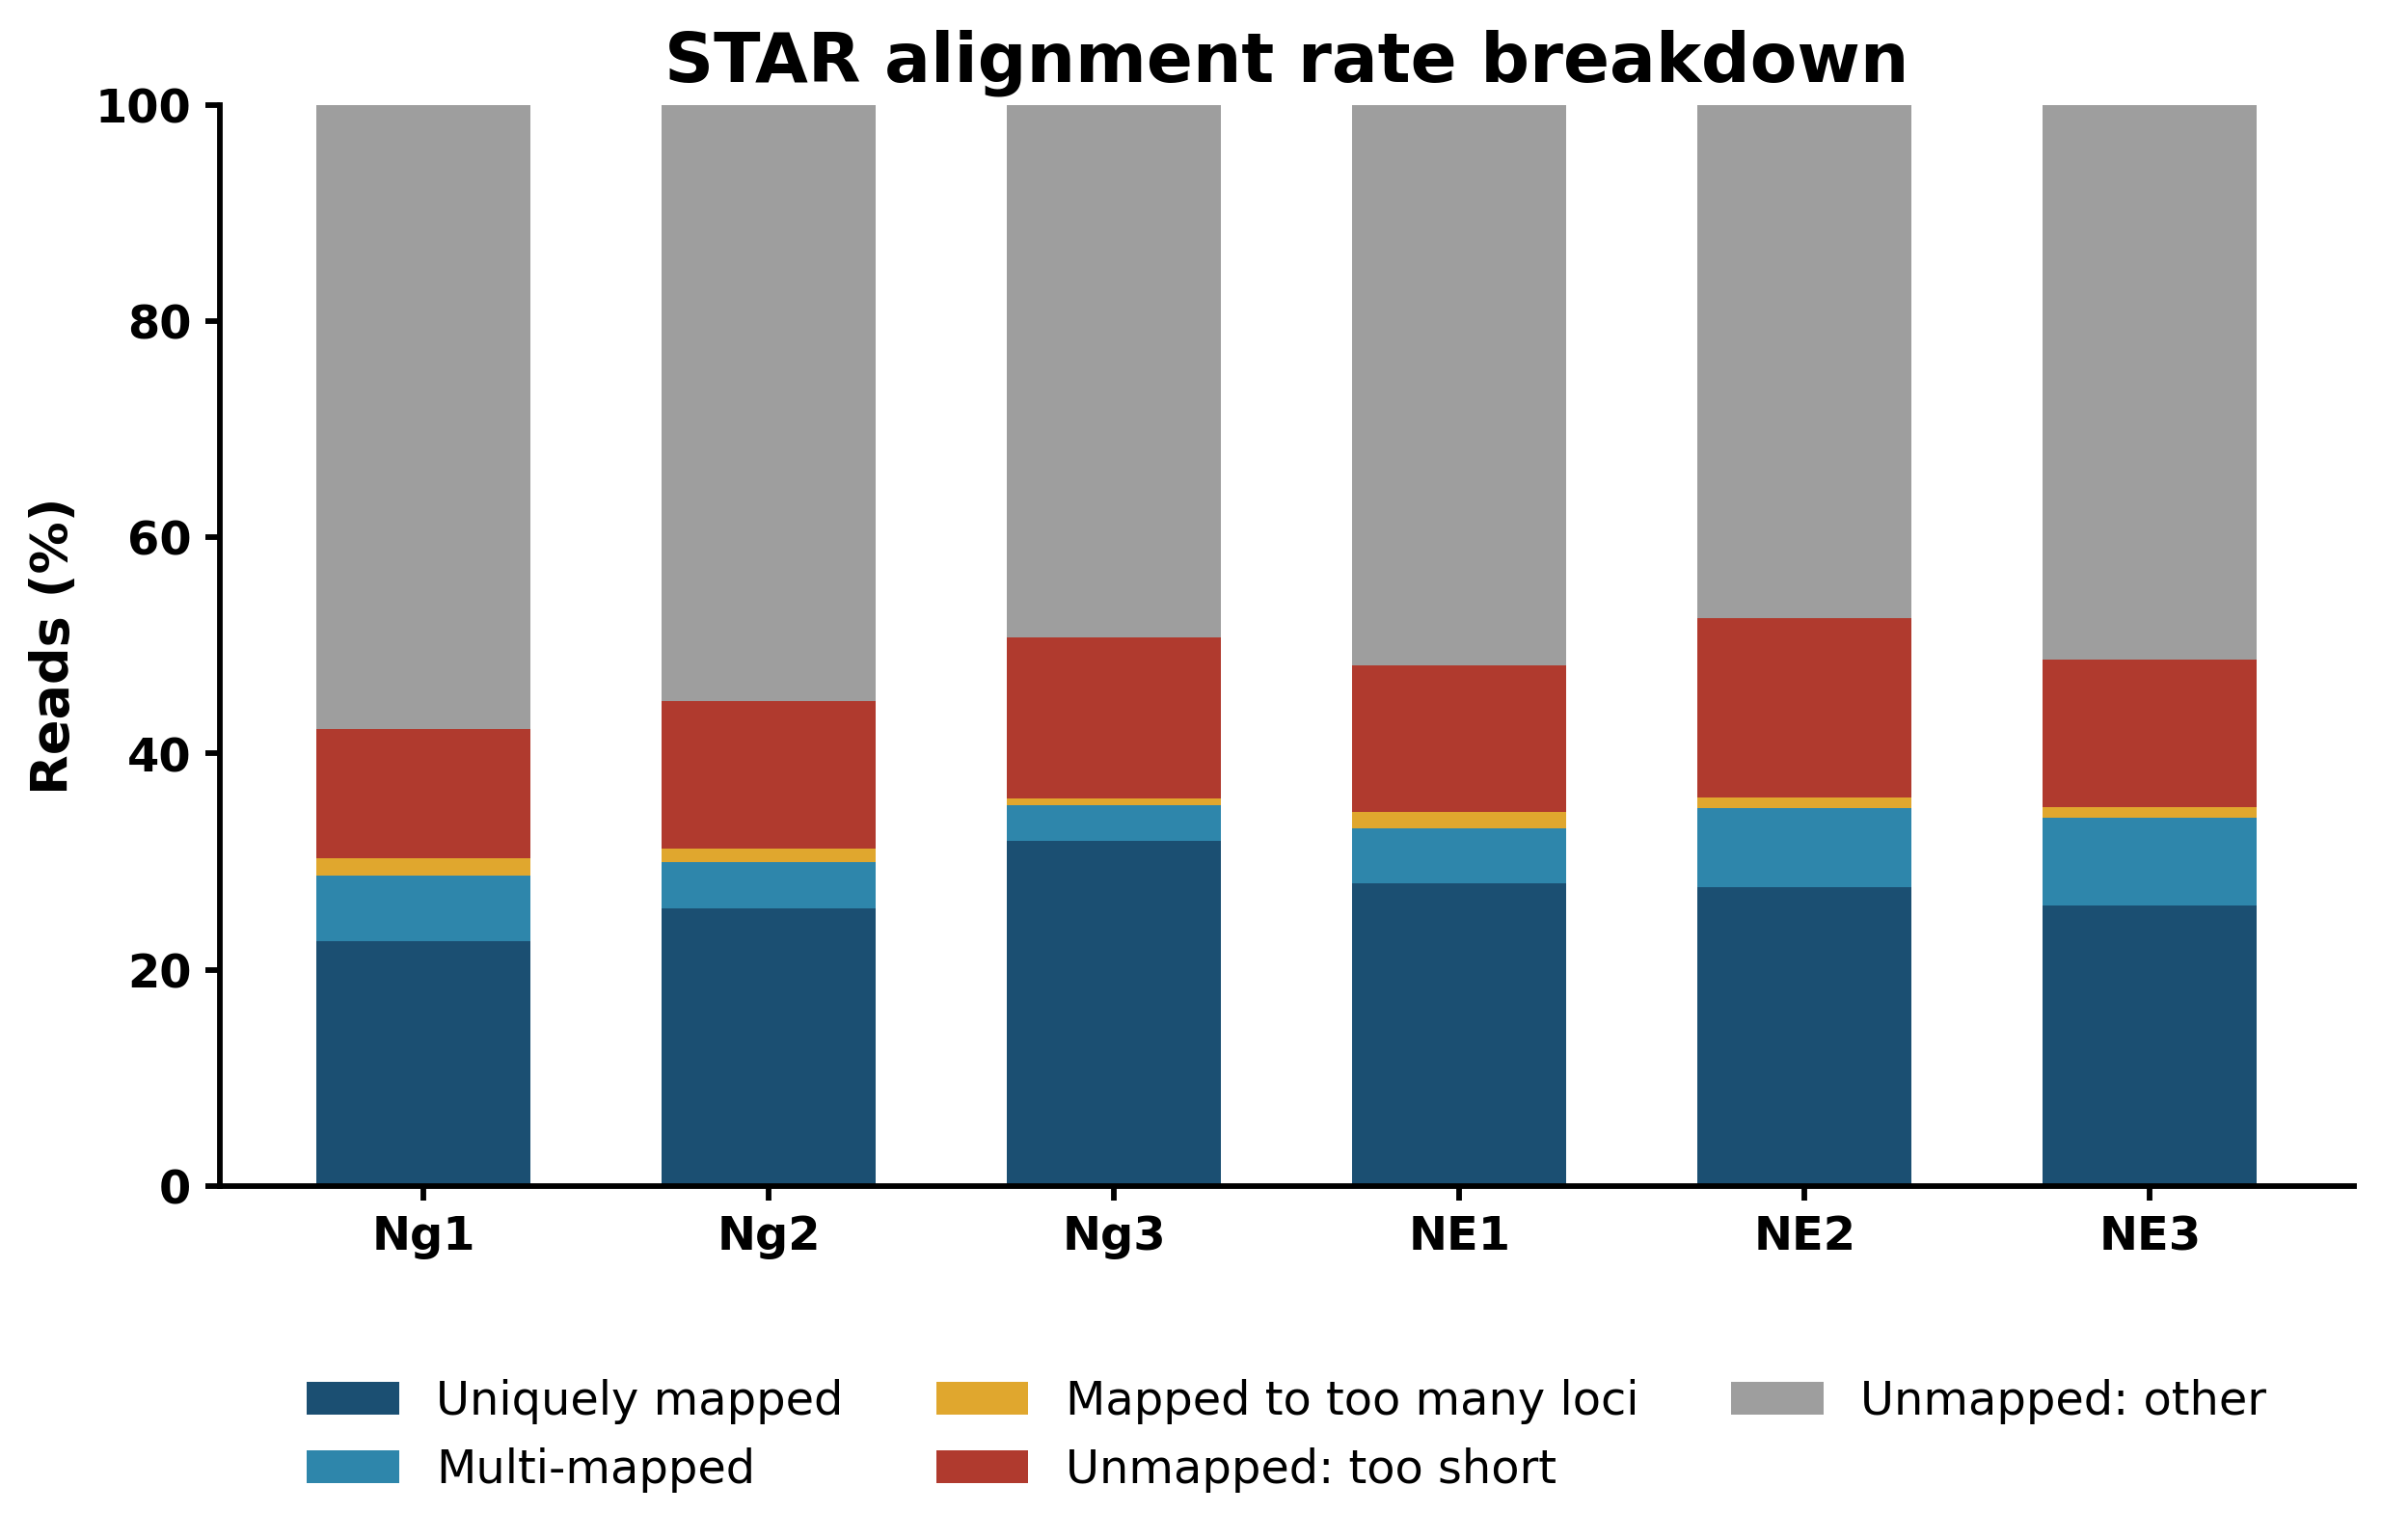

In [6]:
categories = [
    ("uniquely_mapped", "Uniquely mapped", "#1B4F72"),
    ("multimapped", "Multi-mapped", "#2E86AB"),
    ("multimapped_toomany", "Mapped to too many loci", "#E0A72E"),
    ("unmapped_tooshort", "Unmapped: too short", "#B03A2E"),
    ("unmapped_other", "Unmapped: other", "#9E9E9E"),
]

alignment_pct = pd.DataFrame({
    label: star[col] / star["total_reads"] * 100
    for col, label, _ in categories
}, index=SAMPLES)

fig, ax = plt.subplots(figsize=(8.5, 5.5))
bottom = np.zeros(len(SAMPLES))
for col, label, color in categories:
    values = alignment_pct[label].values
    ax.bar(SAMPLES, values, bottom=bottom, label=label, color=color, width=0.62)
    bottom += values

ax.set_ylabel("Reads (%)")
ax.set_ylim(0, 100)
ax.set_title("STAR alignment rate breakdown")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.14), ncol=3, frameon=False)
bold_ticks(ax)

plt.tight_layout()
plt.savefig(FIGDIR / "03_star_alignment.png", bbox_inches="tight")
plt.show()

**Fragments assigned to transcripts (Salmon)**

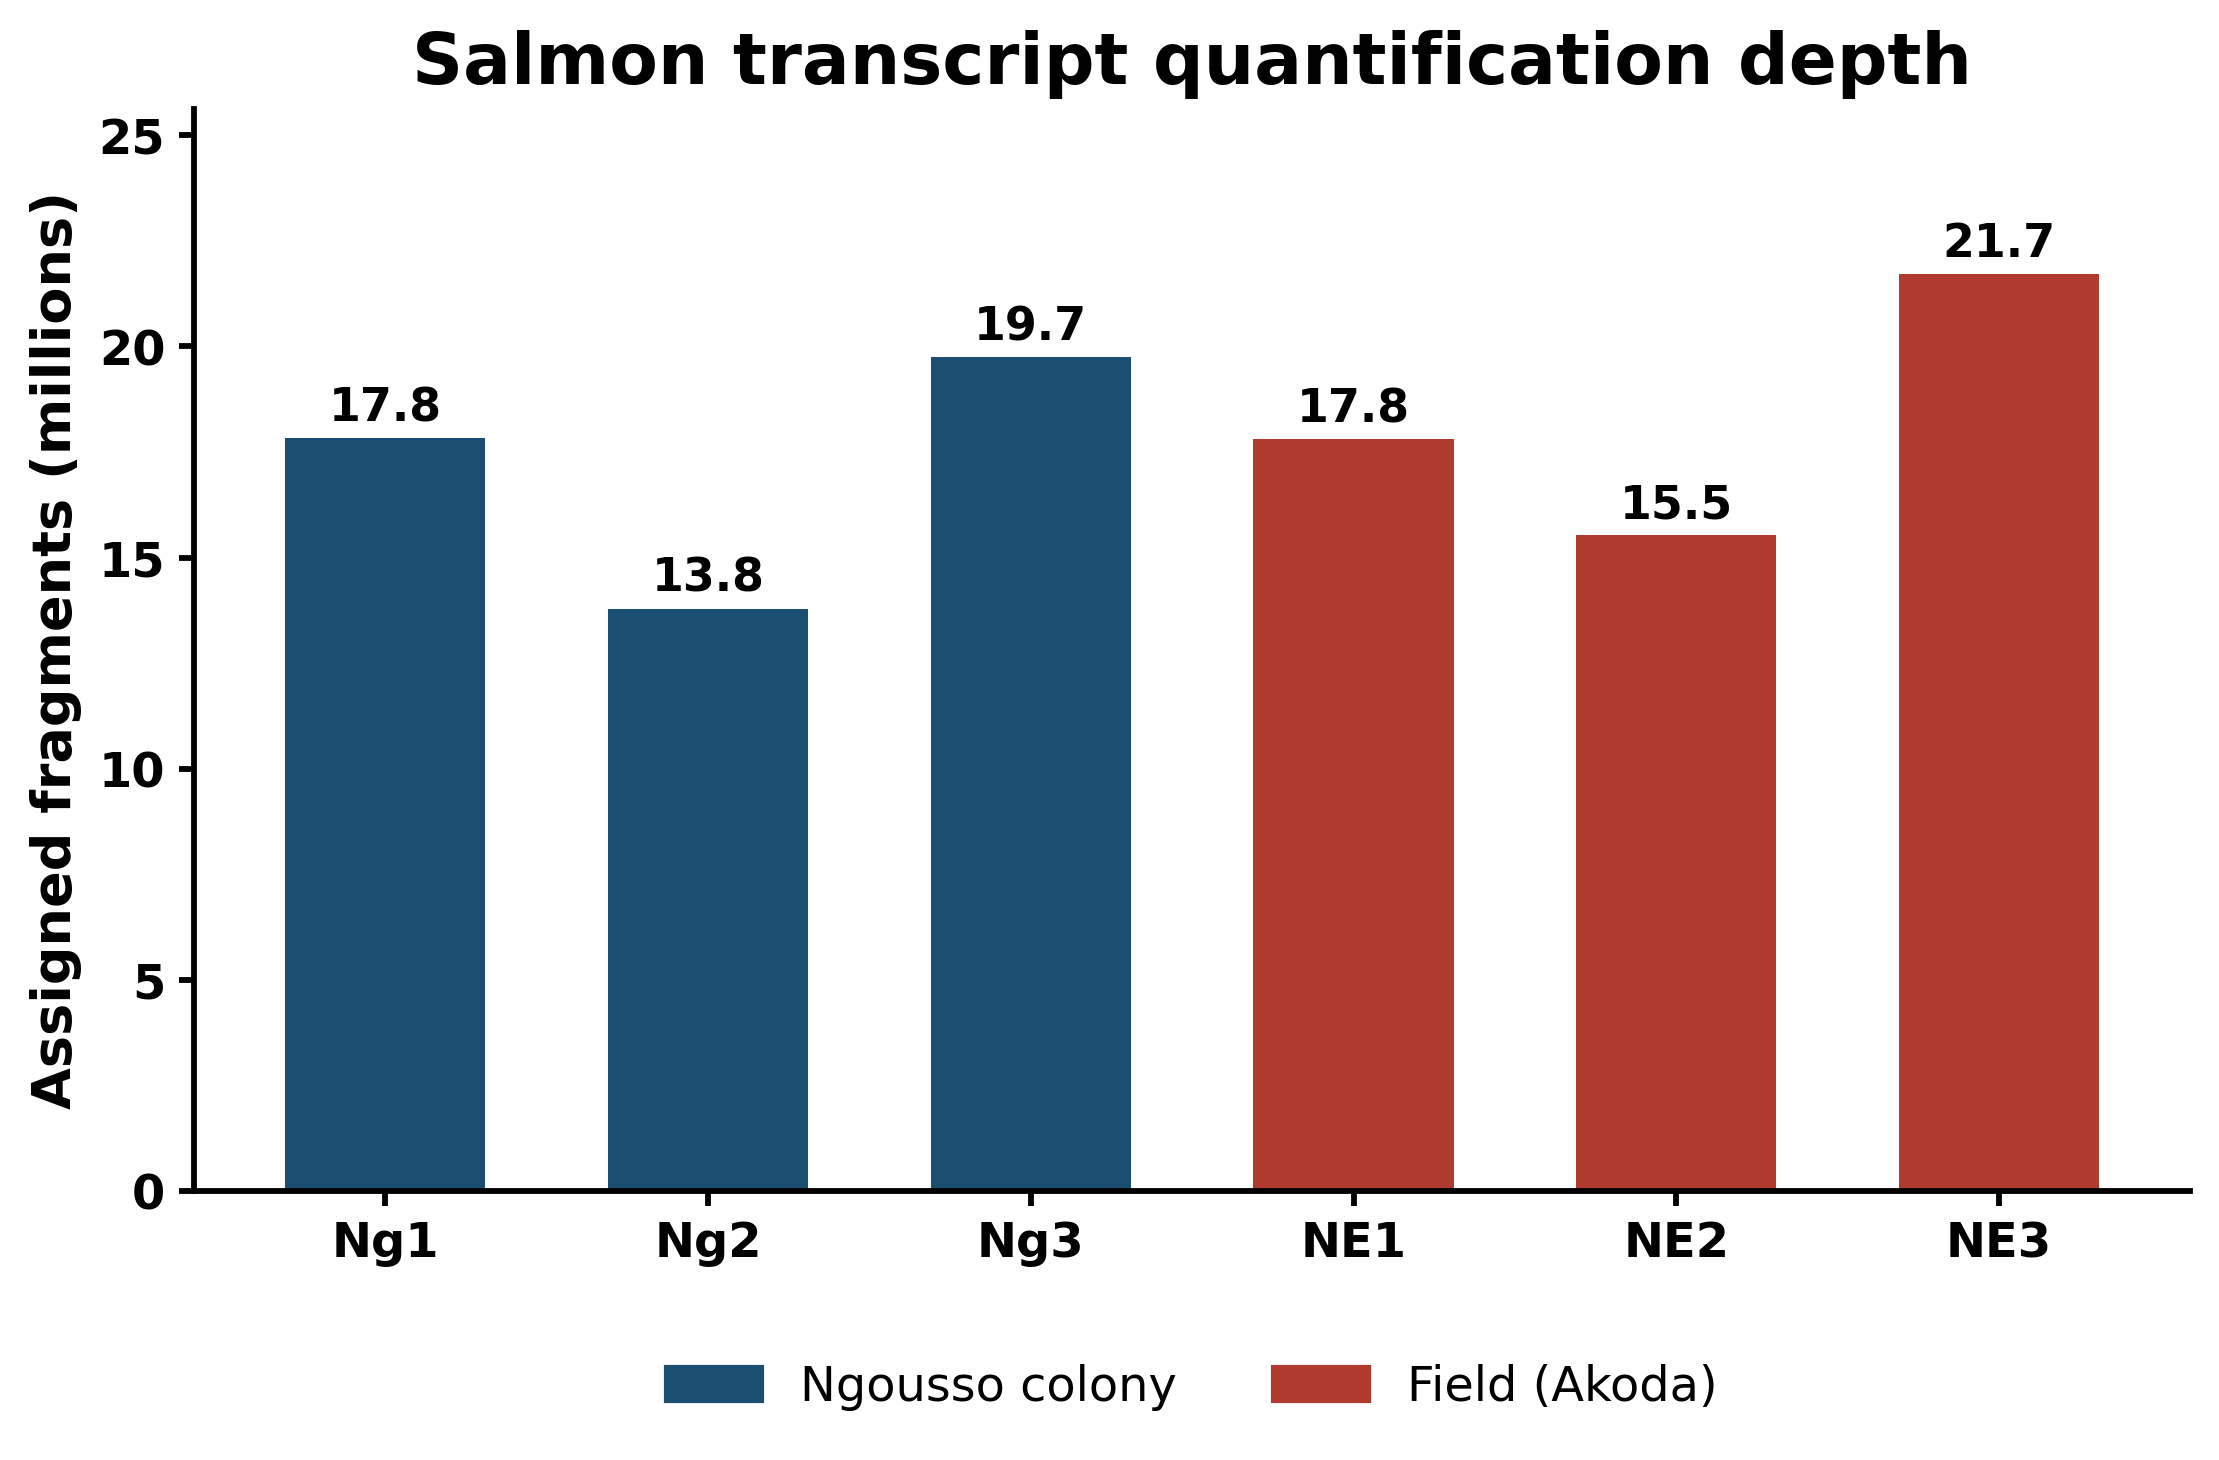

In [7]:
fig, ax = plt.subplots(figsize=(7.5, 5))
values = salmon.loc[SAMPLES, "num_mapped"] / 1e6
bars = ax.bar(SAMPLES, values, color=[SAMPLE_COLOR[s] for s in SAMPLES], width=0.62)

for bar, value in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, value + 0.4, f"{value:.1f}", ha="center", fontsize=11, fontweight="bold")

ax.set_ylabel("Assigned fragments (millions)")
ax.set_ylim(0, values.max() * 1.18)
ax.set_title("Salmon transcript quantification depth")
ax.legend(
    handles=[plt.Rectangle((0, 0), 1, 1, color=GROUP_COLOR[g]) for g in GROUP_COLOR],
    labels=list(GROUP_COLOR.keys()),
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=2,
    frameon=False,
)
bold_ticks(ax)

plt.tight_layout()
plt.savefig(FIGDIR / "04_salmon_mapping.png", bbox_inches="tight")
plt.show()

**Sample-to-sample similarity from transcript quantification**

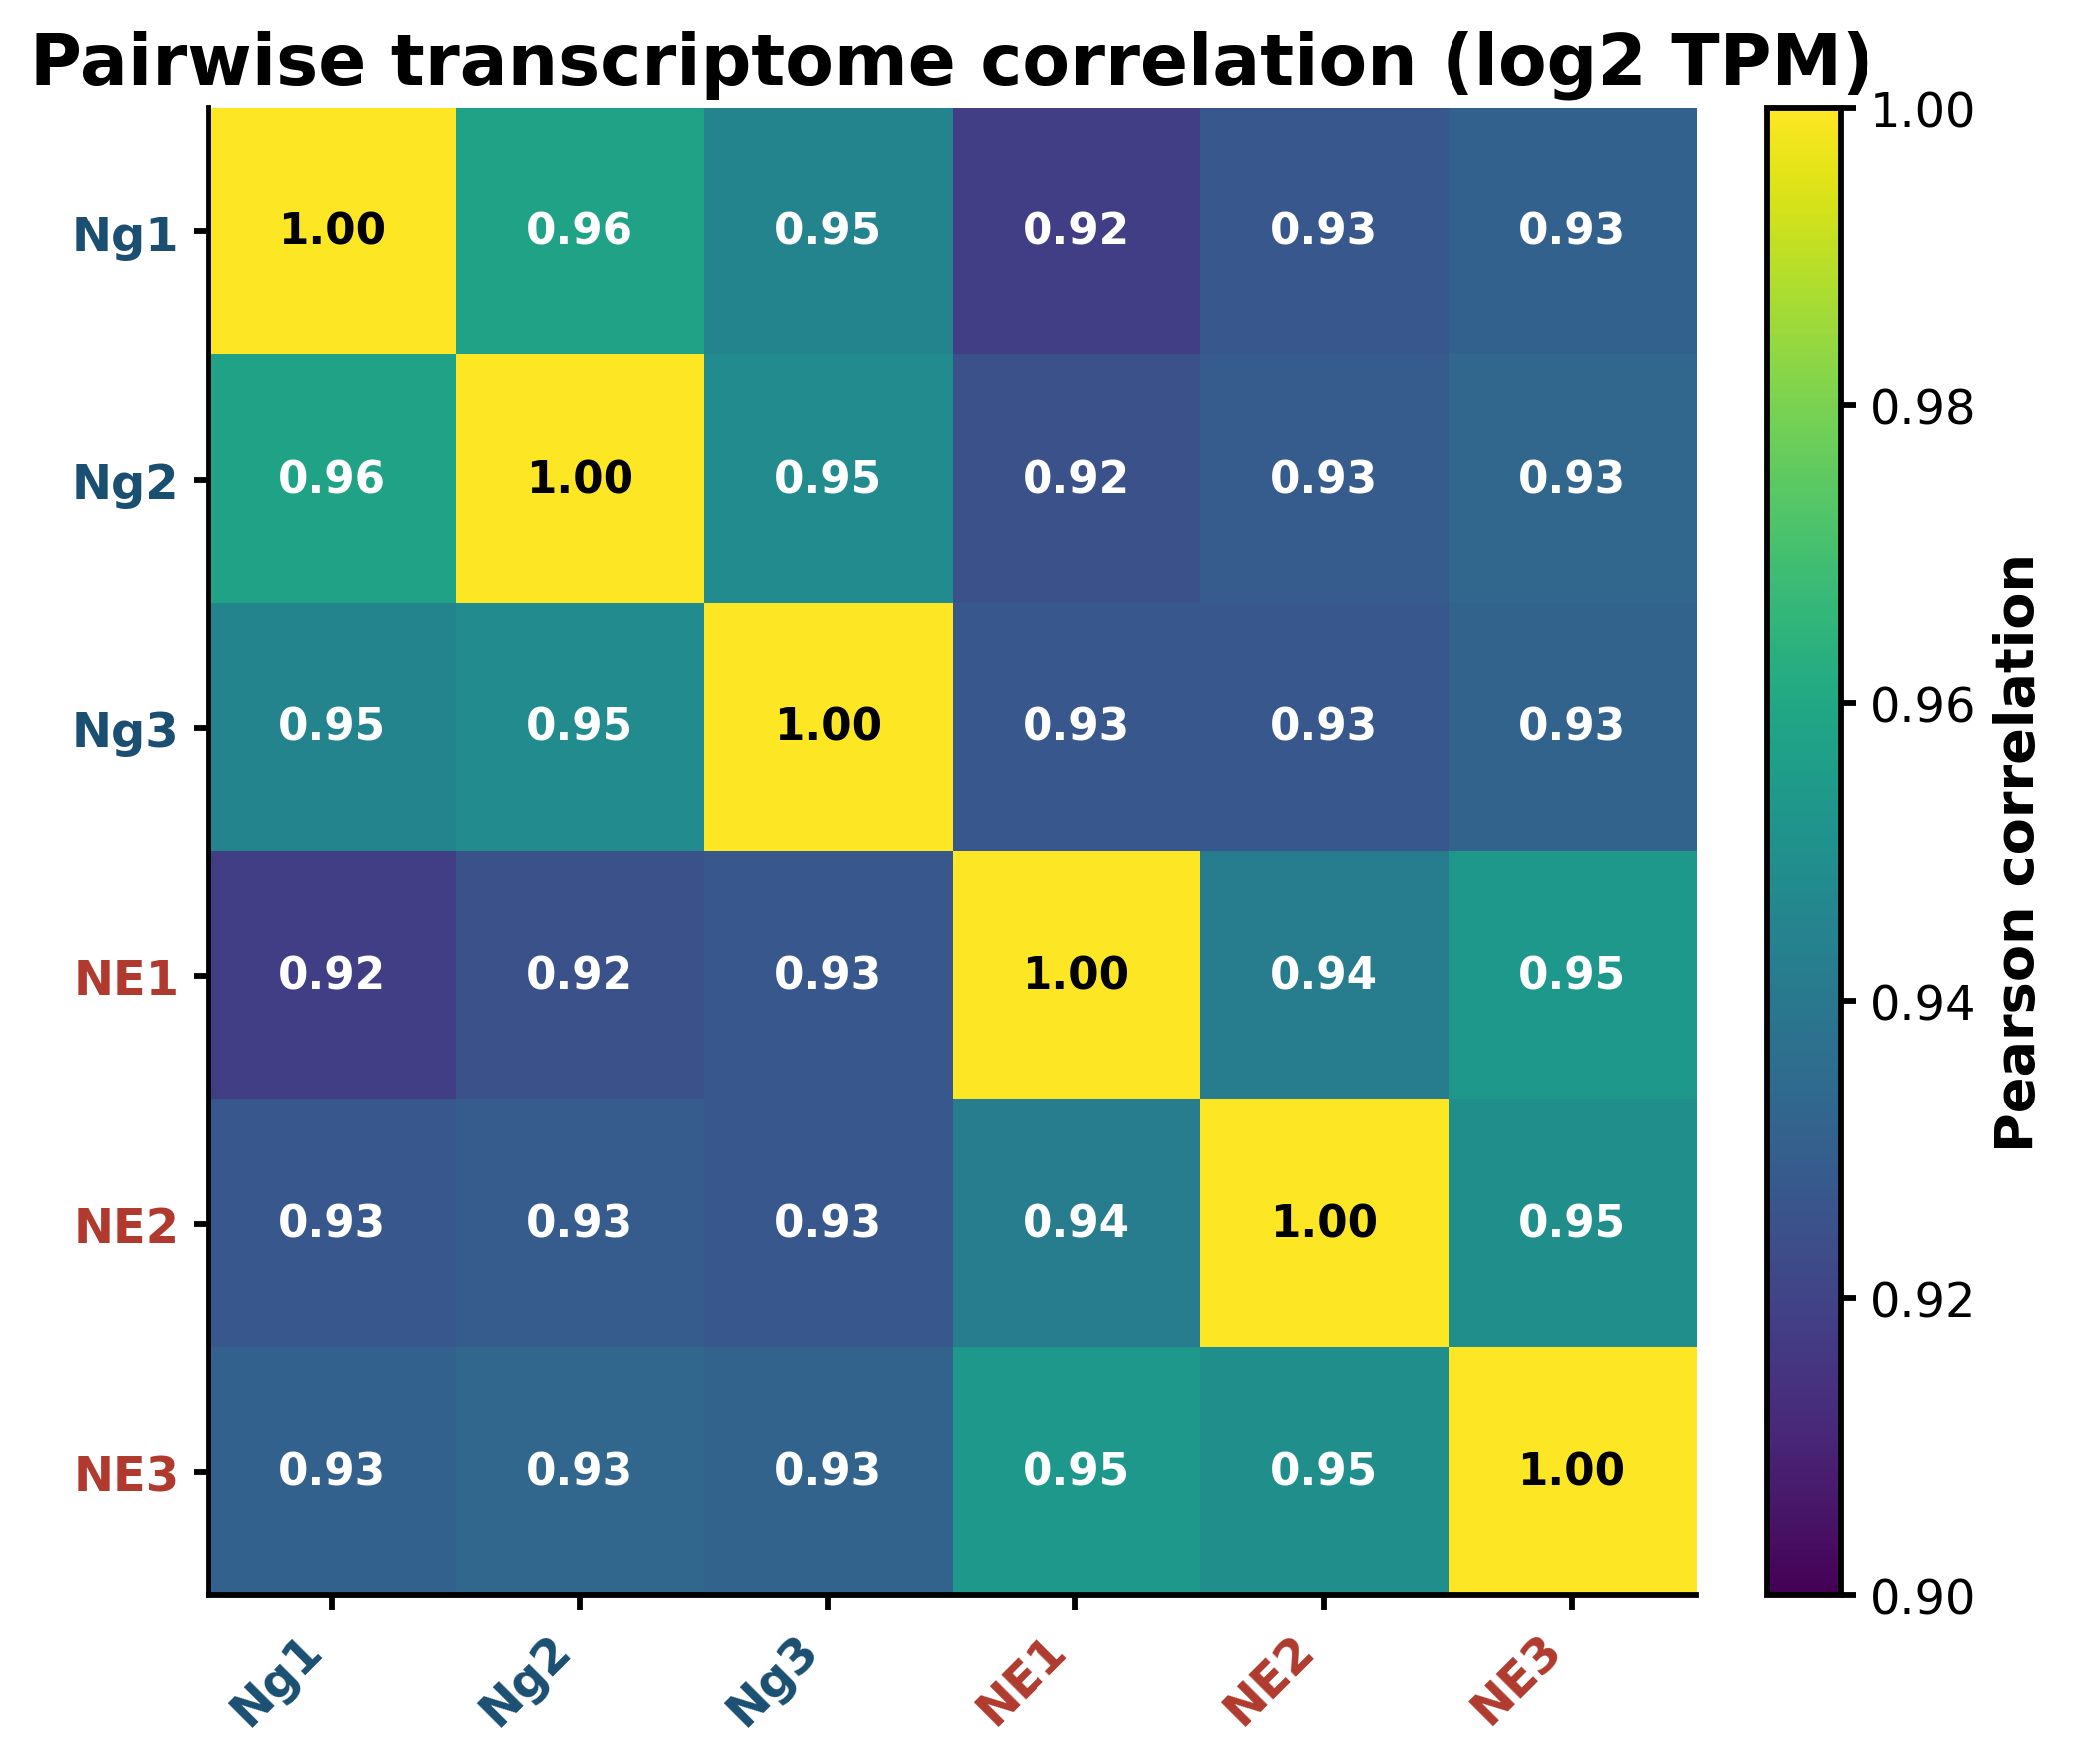

In [8]:
tpm = {}
for sample in SAMPLES:
    quant = pd.read_csv(SALMON_DIR / sample / "quant.sf", sep="\t")
    tpm[sample] = quant.set_index("Name")["TPM"]

tpm_matrix = pd.DataFrame(tpm)
log_tpm = np.log2(tpm_matrix + 1)
correlation = log_tpm.corr().loc[SAMPLES, SAMPLES]

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(correlation, cmap="viridis", vmin=0.90, vmax=1.0)

ax.set_xticks(range(len(SAMPLES)))
ax.set_yticks(range(len(SAMPLES)))
ax.set_xticklabels(SAMPLES, rotation=45, ha="right")
ax.set_yticklabels(SAMPLES)

for label, sample in zip(ax.get_xticklabels(), SAMPLES):
    label.set_color(SAMPLE_COLOR[sample])
for label, sample in zip(ax.get_yticklabels(), SAMPLES):
    label.set_color(SAMPLE_COLOR[sample])

for i in range(len(SAMPLES)):
    for j in range(len(SAMPLES)):
        value = correlation.values[i, j]
        text_color = "white" if value < 0.965 else "black"
        ax.text(j, i, f"{value:.2f}", ha="center", va="center", color=text_color, fontsize=10.5, fontweight="bold")

bold_ticks(ax)
ax.set_title("Pairwise transcriptome correlation (log2 TPM)")
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Pearson correlation", fontweight="bold")

plt.tight_layout()
plt.savefig(FIGDIR / "05_sample_correlation.png", bbox_inches="tight")
plt.show()

**Shared and group-specific transcripts**

In [9]:
from matplotlib.patches import Circle

TABLEDIR = Path("tables")
TABLEDIR.mkdir(exist_ok=True)

DETECTION_TPM = 1.0
MIN_REPLICATES = 2

ngousso_samples = [s for s in SAMPLES if GROUP[s] == "Ngousso colony"]
field_samples = [s for s in SAMPLES if GROUP[s] == "Field (Akoda)"]

detected = tpm_matrix >= DETECTION_TPM
ngousso_detected = detected[ngousso_samples].sum(axis=1) >= MIN_REPLICATES
field_detected = detected[field_samples].sum(axis=1) >= MIN_REPLICATES

category = np.select(
    [ngousso_detected & field_detected, ngousso_detected & ~field_detected, ~ngousso_detected & field_detected],
    ["Shared", "Ngousso colony only", "Field (Akoda) only"],
    default="Not detected",
)

transcript_table = tpm_matrix.round(2).copy()
transcript_table.insert(0, "category", category)
transcript_table = transcript_table.reset_index().rename(columns={"Name": "transcript_id"})

category_order = ["Shared", "Ngousso colony only", "Field (Akoda) only", "Not detected"]
category_counts = transcript_table["category"].value_counts().reindex(category_order).fillna(0).astype(int)
category_counts

category
Shared                 12721
Ngousso colony only     1837
Field (Akoda) only       851
Not detected           11415
Name: count, dtype: int64

**Export transcript categories to Excel**

In [10]:
excel_path = TABLEDIR / "shared_vs_group_specific_transcripts.xlsx"

with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
    category_counts.rename("transcript_count").to_frame().to_excel(writer, sheet_name="summary")
    transcript_table.to_excel(writer, sheet_name="transcripts", index=False)

excel_path

PosixPath('tables/shared_vs_group_specific_transcripts.xlsx')

**Overlap between Ngousso colony and field-collected transcript sets**

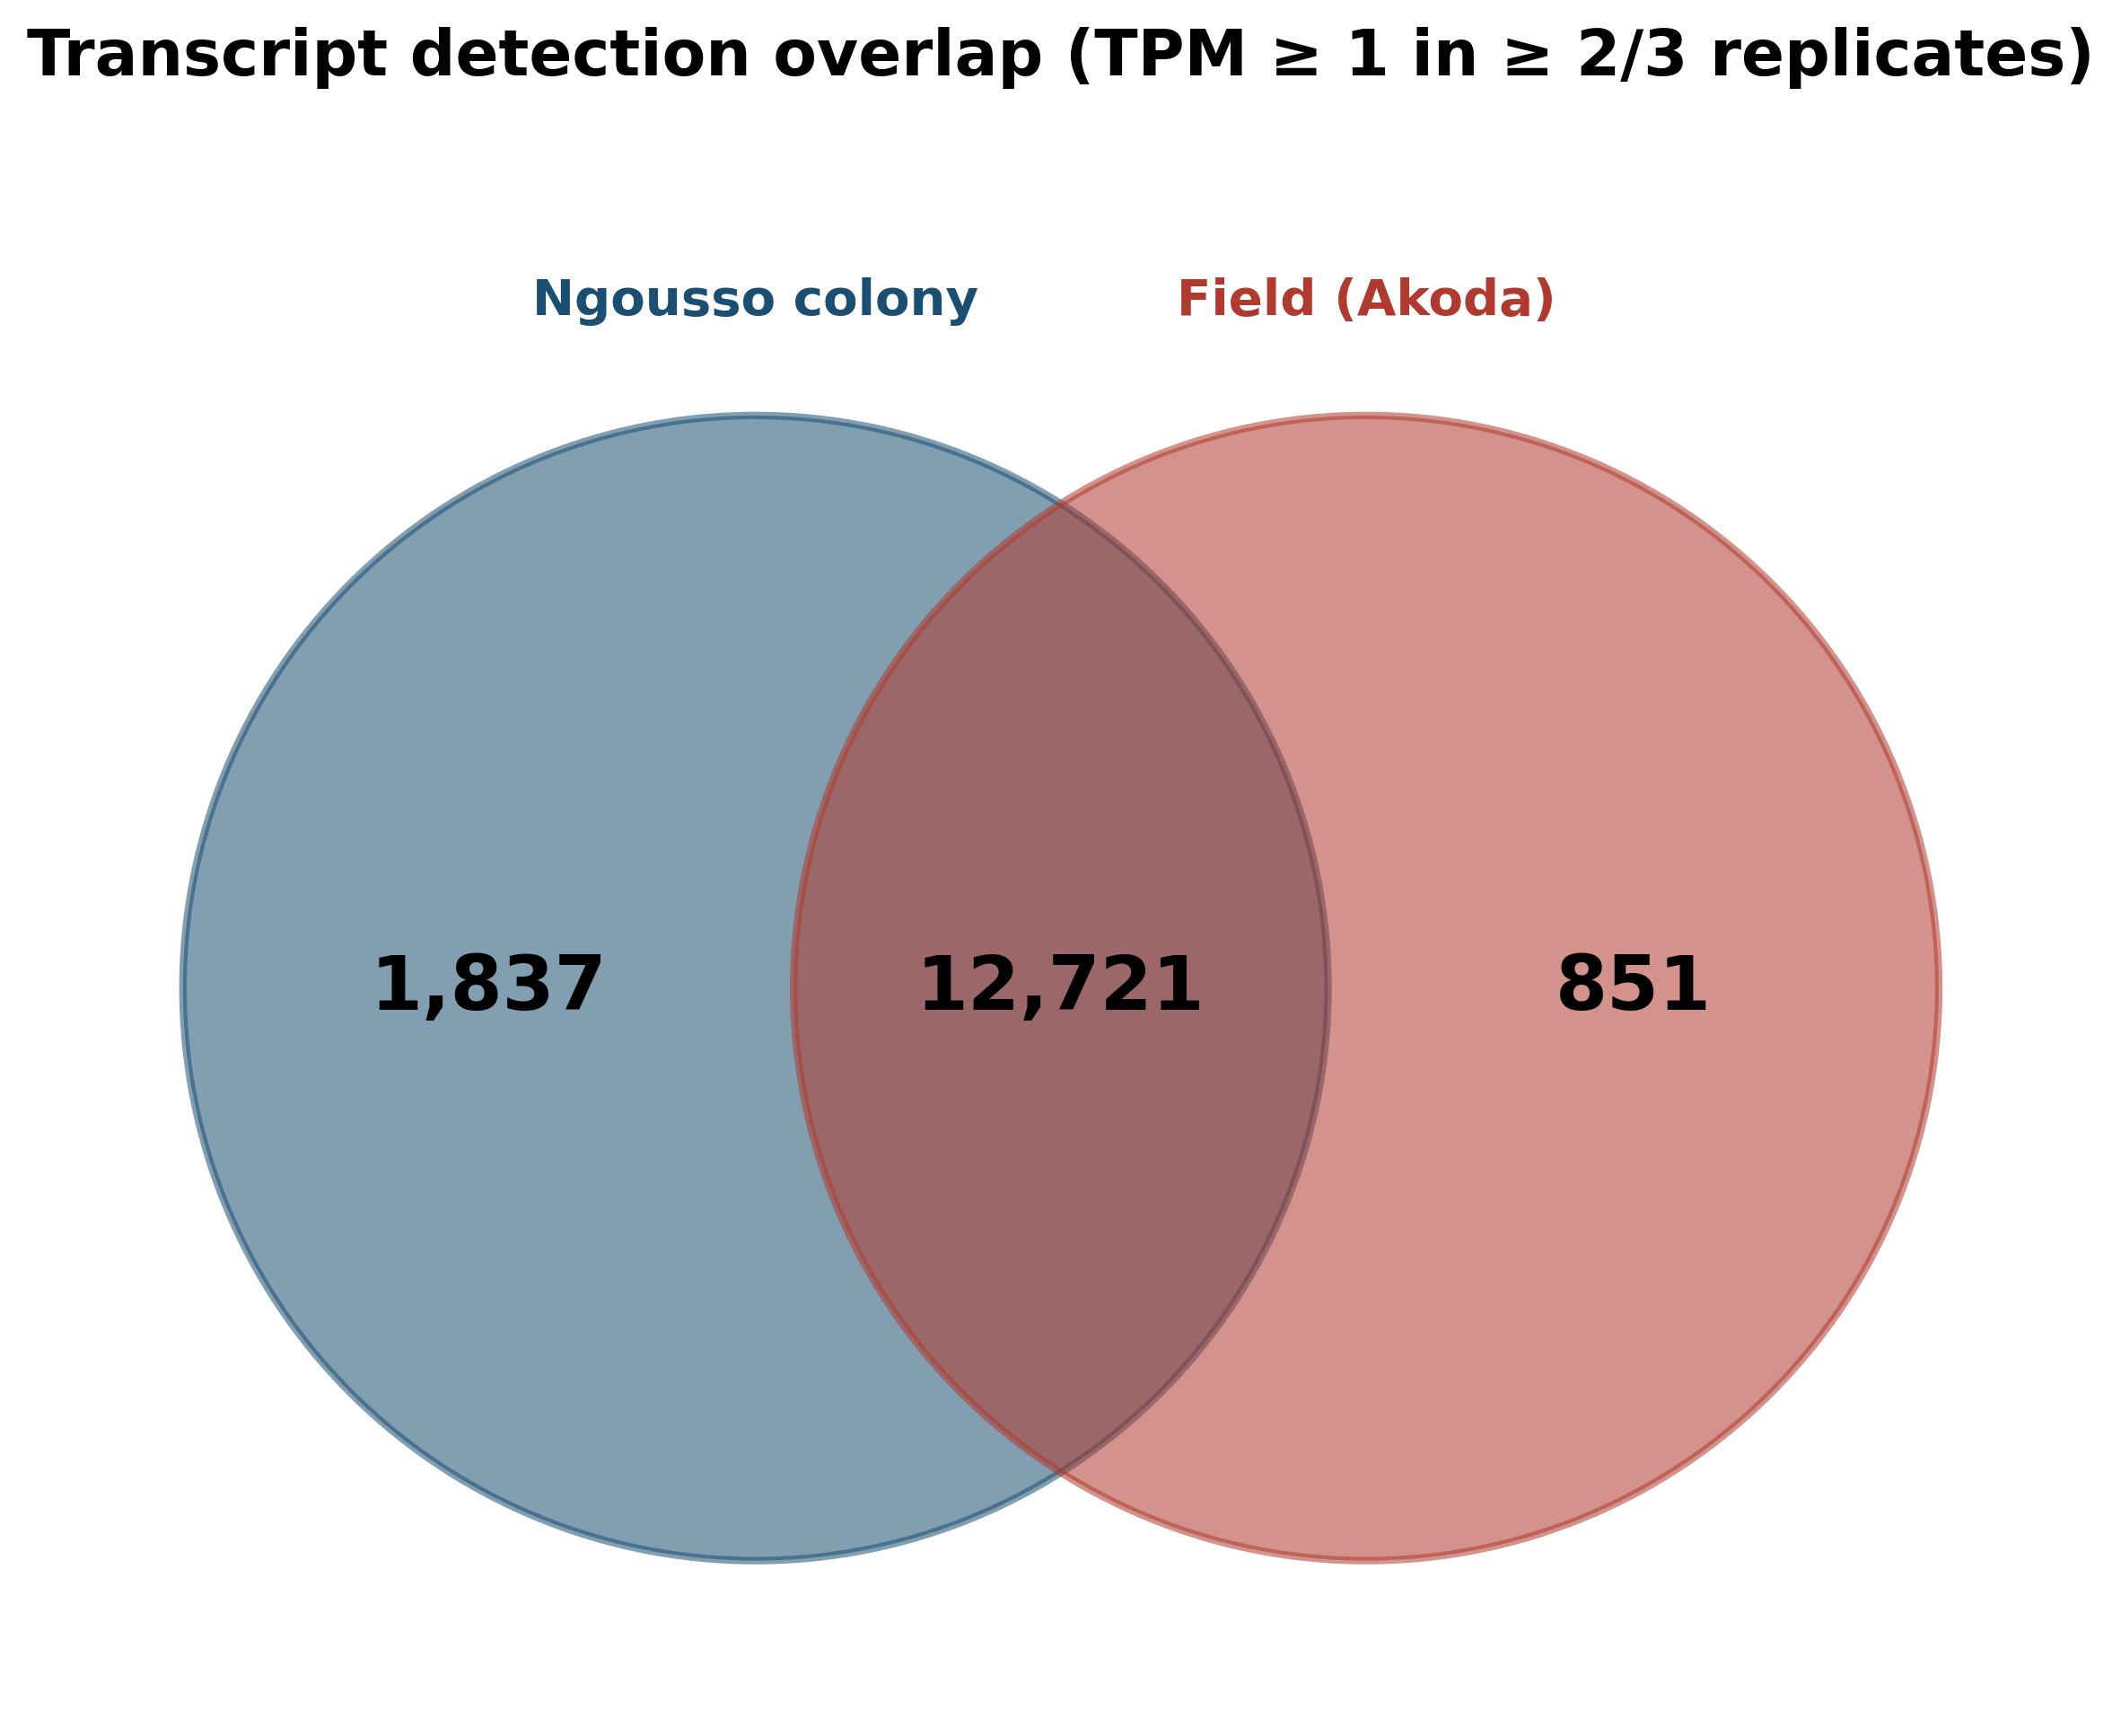

In [11]:
n_shared = category_counts["Shared"]
n_ngousso_only = category_counts["Ngousso colony only"]
n_field_only = category_counts["Field (Akoda) only"]

fig, ax = plt.subplots(figsize=(8, 6.5))

left_circle = Circle((-0.72, 0), 1.35, color=GROUP_COLOR["Ngousso colony"], alpha=0.55, linewidth=2, edgecolor="white")
right_circle = Circle((0.72, 0), 1.35, color=GROUP_COLOR["Field (Akoda)"], alpha=0.55, linewidth=2, edgecolor="white")
ax.add_patch(left_circle)
ax.add_patch(right_circle)

ax.text(-1.35, 0, f"{n_ngousso_only:,}", ha="center", va="center", fontsize=20, fontweight="bold")
ax.text(1.35, 0, f"{n_field_only:,}", ha="center", va="center", fontsize=20, fontweight="bold")
ax.text(0, 0, f"{n_shared:,}", ha="center", va="center", fontsize=20, fontweight="bold")

ax.text(-0.72, 1.62, "Ngousso colony", ha="center", va="center", fontsize=13.5, fontweight="bold", color=GROUP_COLOR["Ngousso colony"])
ax.text(0.72, 1.62, "Field (Akoda)", ha="center", va="center", fontsize=13.5, fontweight="bold", color=GROUP_COLOR["Field (Akoda)"])

ax.set_xlim(-2.4, 2.4)
ax.set_ylim(-1.7, 2.1)
ax.set_aspect("equal")
ax.axis("off")
ax.set_title("Transcript detection overlap (TPM ≥ 1 in ≥ 2/3 replicates)")

plt.tight_layout()
plt.savefig(FIGDIR / "06_transcript_overlap_venn.png", bbox_inches="tight")
plt.show()

**Transcript category counts**

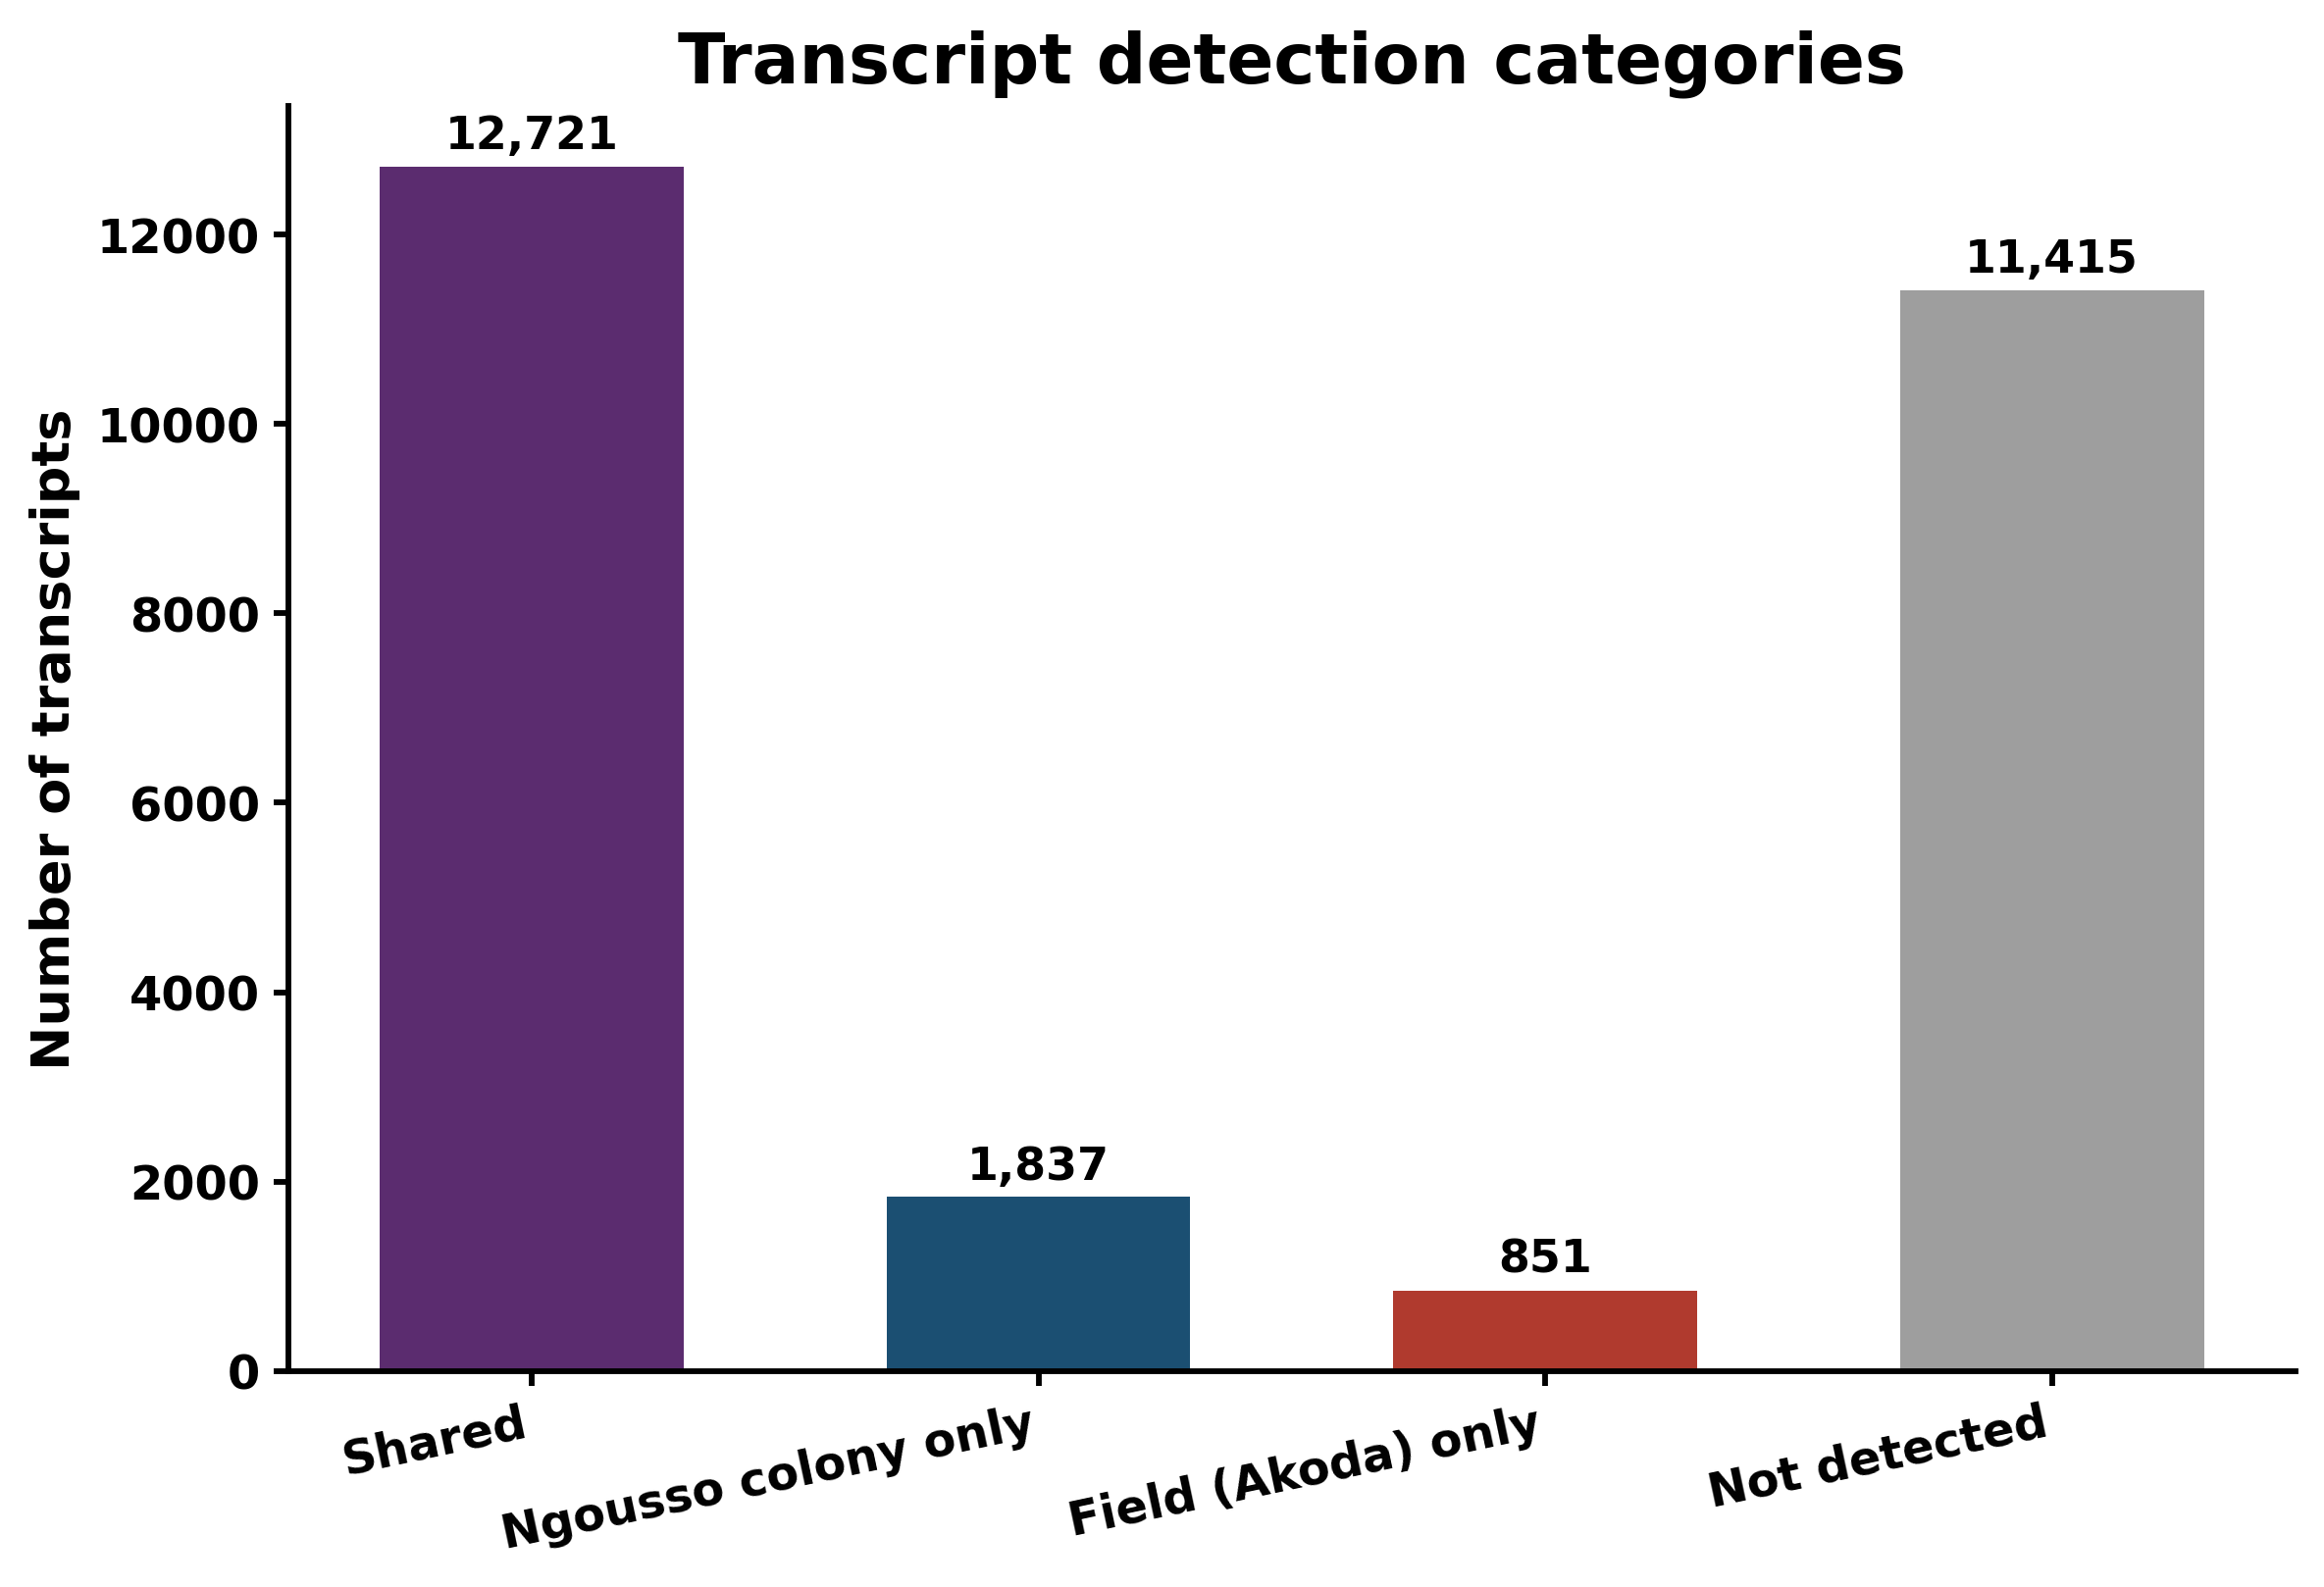

In [12]:
colors = [GROUP_COLOR["Ngousso colony"], GROUP_COLOR["Ngousso colony"], GROUP_COLOR["Field (Akoda)"], "#9E9E9E"]
colors[0] = "#5B2C6F"

fig, ax = plt.subplots(figsize=(8, 5.5))
bars = ax.bar(category_counts.index, category_counts.values, color=colors, width=0.6)

for bar, value in zip(bars, category_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, value + max(category_counts.values) * 0.015, f"{value:,}", ha="center", fontsize=11, fontweight="bold")

ax.set_ylabel("Number of transcripts")
ax.set_title("Transcript detection categories")
bold_ticks(ax)
plt.setp(ax.get_xticklabels(), rotation=12, ha="right")

plt.tight_layout()
plt.savefig(FIGDIR / "07_transcript_categories.png", bbox_inches="tight")
plt.show()